# European Inflation Analysis

This project analyzes inflation trends in Europe using Eurostat data.

In [9]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

In [10]:
conn = psycopg2.connect(
    host = "localhost",
    dbname = "financial_db",
    user = "postgres",
    password = "postgre123" 
)

query = "SELECT * FROM inflation_eu"

#Loading
df = pd.read_sql(query,conn)

#Cleaning
df = df.drop_duplicates()

#Aggregating
df = df.groupby("time")["valeur"].mean().reset_index()

#Preparing
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop = True)

df.head()

C:\Users\john-\AppData\Local\Temp\ipykernel_21320\291237650.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,time,valeur
0,1996-01-01,81.783333
1,1996-02-01,81.863333
2,1996-03-01,81.950000
3,1996-04-01,82.113333
4,1996-05-01,82.193333


In [11]:
#Monthly Inflation (variation %)

df["inflation_mom"] = df["valeur"].pct_change()*100

In [12]:
#Smooth Inflation

df["inflation_smooth"] = df["valeur"].rolling(window=12).mean()

In [16]:
#Checking

#df.head()
#df.tail()

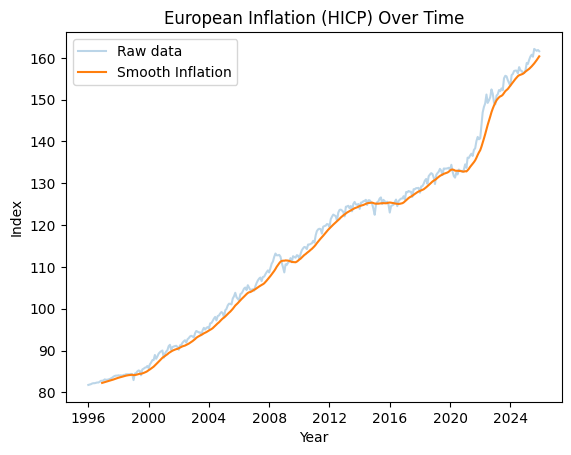

In [18]:
plt.figure()

plt.plot(df["time"], df["valeur"], alpha=0.3, label="Raw data")
plt.plot(df["time"], df["inflation_smooth"], label = "Smooth Inflation")

plt.title("European Inflation (HICP) Over Time")
plt.xlabel("Year")
plt.ylabel("Index")
plt.legend()

plt.show()

## Key Insights

- Inflation steadily increased from 1996 to 2008
- Stability period between 2010-2019
- Sharp increase after 2021 (post-COVID + energy crisis)

HICP = Harmonised Index of Consumer Prices. It is an index that measures changes in the prices of goods and services consumed by households.